In [32]:
import pandas as pd
import os
import re
from collections import Counter

# --- CONFIGURATION ---
# Make sure this path is correct relative to your Jupyter Notebook's location.
CSV_FILE_PATH = "master_dataset_v6.csv" 

# This dictionary maps the full website names found in the 'task_id' 
# to the abbreviated names you want to display.
# Add or modify mappings here if your task_ids use different names.
WEBSITE_MAP = {
    "Allrecipes": "Allr.",
    "Amazon": "Amaz.",
    "Apple": "Appl.",
    "ArXiv": "ArXiv",
    "GitHub": "GitH.",
    "Booking": "Book.",
    "ESPN": "ESPN",
    "Coursera": "Cour.",
    "Cambridge Dictionary": "Cambr.",
    "BBC News": "BBC",
    "Google Flights": "G.Flg.",
    "Google Map": "G.Map",
    "Google Search": "G.Srch",
    "Huggingface": "Hug.",
    "Wolfram Alpha": "Wolf."
    # The original paper also had 'Overall' but that's not a website.
}

# The list of abbreviations to ensure all are printed, even with a count of 0.
WEBSITE_ABBREVIATIONS = [
    "Allr.", "Amaz.", "Appl.", "ArXiv", "GitH.", "Book.", "ESPN", 
    "Cour.", "Cambr.", "BBC", "G.Flg.", "G.Map", "G.Srch", "Hug.", "Wolf."
]

# --- DATA LOADING AND PREPARATION ---

print(f"Attempting to load dataset from: {CSV_FILE_PATH}\n")

if not os.path.exists(CSV_FILE_PATH):
    print(" ERROR: The dataset file was not found. Please check the CSV_FILE_PATH.")
    print("         Make sure the auto_labeler.py script has run and created the file.")
else:
    try:
        # Load the dataset using pandas
        df = pd.read_csv(CSV_FILE_PATH)

        if df.empty:
            print(" The dataset file is empty. Waiting for the auto_labeler to add data.")
        else:
            # --- ANALYSIS 1: SCREENSHOT COUNT PER WEBSITE ---
            print(" Analysis 1: Screenshot Count per Website")
            print("-" * 45)

            # Function to extract the website name from a task_id (e.g., 'taskAllrecipes--0')
            def extract_website(task_id):
                # This regex looks for text between 'task' and '--'
                match = re.search(r'task(.*?)(--\d+)', task_id)
                if match:
                    # Map the full name to its abbreviation, default to the full name if not in map
                    full_name = match.group(1)
                    return WEBSITE_MAP.get(full_name, full_name) 
                return "Unknown"

            # Create a new 'website' column by applying the function
            df['website'] = df['task_id'].apply(extract_website)

            # Get the counts for each website
            website_counts = df['website'].value_counts()
            
            # Ensure all websites from our list are present in the output, even if their count is 0
            website_counts = website_counts.reindex(WEBSITE_ABBREVIATIONS, fill_value=0)

            print(f"{'Website':<10} | {'Screenshot Count':<20}")
            print(f"{'-'*10:}|{'-'*20}")
            for website, count in website_counts.items():
                print(f"{website:<10} | {count:<20}")
            print("-" * 45)
            print(f"{'TOTAL':<10} | {len(df):<20}\n\n")


            # --- ANALYSIS 2: SCREENSHOT COUNT PER LABEL ---
            print(" Analysis 2: Screenshot Count per Label")
            print("-" * 55)

            # Get the counts for each label
            label_counts = df['label'].value_counts()
            total_images = len(df)

            print(f"{'Label':<25} | {'Count':<10} | {'Percentage':<15}")
            print(f"{'-'*25:}|{'-'*10:}|{'-'*15}")
            for label, count in label_counts.items():
                percentage = (count / total_images) * 100 if total_images > 0 else 0
                print(f"{label:<25} | {count:<10} | {percentage:.2f}%")
            print("-" * 55)
            
            # Check for any unclassified or error labels
            error_labels = ["MODEL_ERROR", "IMAGE_READ_ERROR", "OTHER", "Unknown"]
            found_errors = df[df['label'].isin(error_labels)]
            if not found_errors.empty:
                print("\n Sanity Check: Found some non-ideal labels.")
                print(found_errors['label'].value_counts())

    except Exception as e:
        print(f"ERROR: Could not process the CSV file. It might be corrupted or in use.")
        print(f"         Error details: {e}")

Attempting to load dataset from: master_dataset_v6.csv

 Analysis 1: Screenshot Count per Website
---------------------------------------------
Website    | Screenshot Count    
----------|--------------------
Allr.      | 624                 
Amaz.      | 541                 
Appl.      | 532                 
ArXiv      | 565                 
GitH.      | 588                 
Book.      | 641                 
ESPN       | 577                 
Cour.      | 593                 
Cambr.     | 425                 
BBC        | 65                  
G.Flg.     | 630                 
G.Map      | 615                 
G.Srch     | 640                 
Hug.       | 526                 
Wolf.      | 408                 
---------------------------------------------
TOTAL      | 7970                


 Analysis 2: Screenshot Count per Label
-------------------------------------------------------
Label                     | Count      | Percentage     
-------------------------|----------|--------

In [33]:
# 357 processed at 18:47
# 479 processed at 18:53

In [34]:
# --- ANALYSIS 3: LABEL DISTRIBUTION PER WEBSITE ---

print("Analysis 3: Label Distribution per Website")
print("=" * 50)

# We can reuse the 'website' column created in the first cell.
# The .groupby() function is perfect for this. We group by 'website'
# and then get the value counts for the 'label' within each group.

# Group the DataFrame by website and then count the labels in each group
label_distribution_per_website = df.groupby('website')['label'].value_counts()

# The result is a multi-index Series. We can iterate through it to print nicely.
for website in WEBSITE_ABBREVIATIONS:
    print(f"\nWebsite: {website}")
    print("-" * 25)
    
    if website in label_distribution_per_website.index:
        # Get the label counts for the current website
        website_labels = label_distribution_per_website[website]
        total_for_website = website_labels.sum()
        
        print(f"{'Label':<25} | {'Count':<10} | {'Percentage':<15}")
        print(f"{'-'*25:}|{'-'*10:}|{'-'*15}")
        
        for label, count in website_labels.items():
            percentage = (count / total_for_website) * 100
            print(f"{label:<25} | {count:<10} | {percentage:>14.2f}%")
            
        print(f"{'-'*25:}|{'-'*10:}|{'-'*15}")
        print(f"{'SUBTOTAL':<25} | {total_for_website:<10} | {'100.00%':>15}")
        
    else:
        # This will print for websites that have 0 images so far
        print("No screenshots processed for this website yet.")

print("\n" + "=" * 50)
print("Analysis Complete.")

Analysis 3: Label Distribution per Website

Website: Allr.
-------------------------
Label                     | Count      | Percentage     
-------------------------|----------|---------------
DETAIL_PAGE               | 173        |          27.72%
SEARCH_RESULTS_LISTING    | 147        |          23.56%
CATEGORY_LISTING          | 86         |          13.78%
HOMEPAGE                  | 58         |           9.29%
SEARCH_OVERLAY_ACTIVE     | 56         |           8.97%
POPUP_OVERLAY             | 51         |           8.17%
ARTICLE_DOCUMENT          | 27         |           4.33%
NAVIGATION_MENU_ACTIVE    | 15         |           2.40%
LOGIN_SIGNUP              | 5          |           0.80%
MODEL_ERROR               | 3          |           0.48%
FILTER_SORT_OPTIONS       | 2          |           0.32%
FORM_PAGE                 | 1          |           0.16%
-------------------------|----------|---------------
SUBTOTAL                  | 624        |         100.00%

Website: A

 Analysis 4: Image Dimensions and Visual Sanity Check

[Part 1] Analyzing dimensions of the first 100 images...

Found 1 unique image dimension(s):
  - Width: 1006px, Height: 620px


[Part 2] Displaying 10 randomly selected images with their labels...


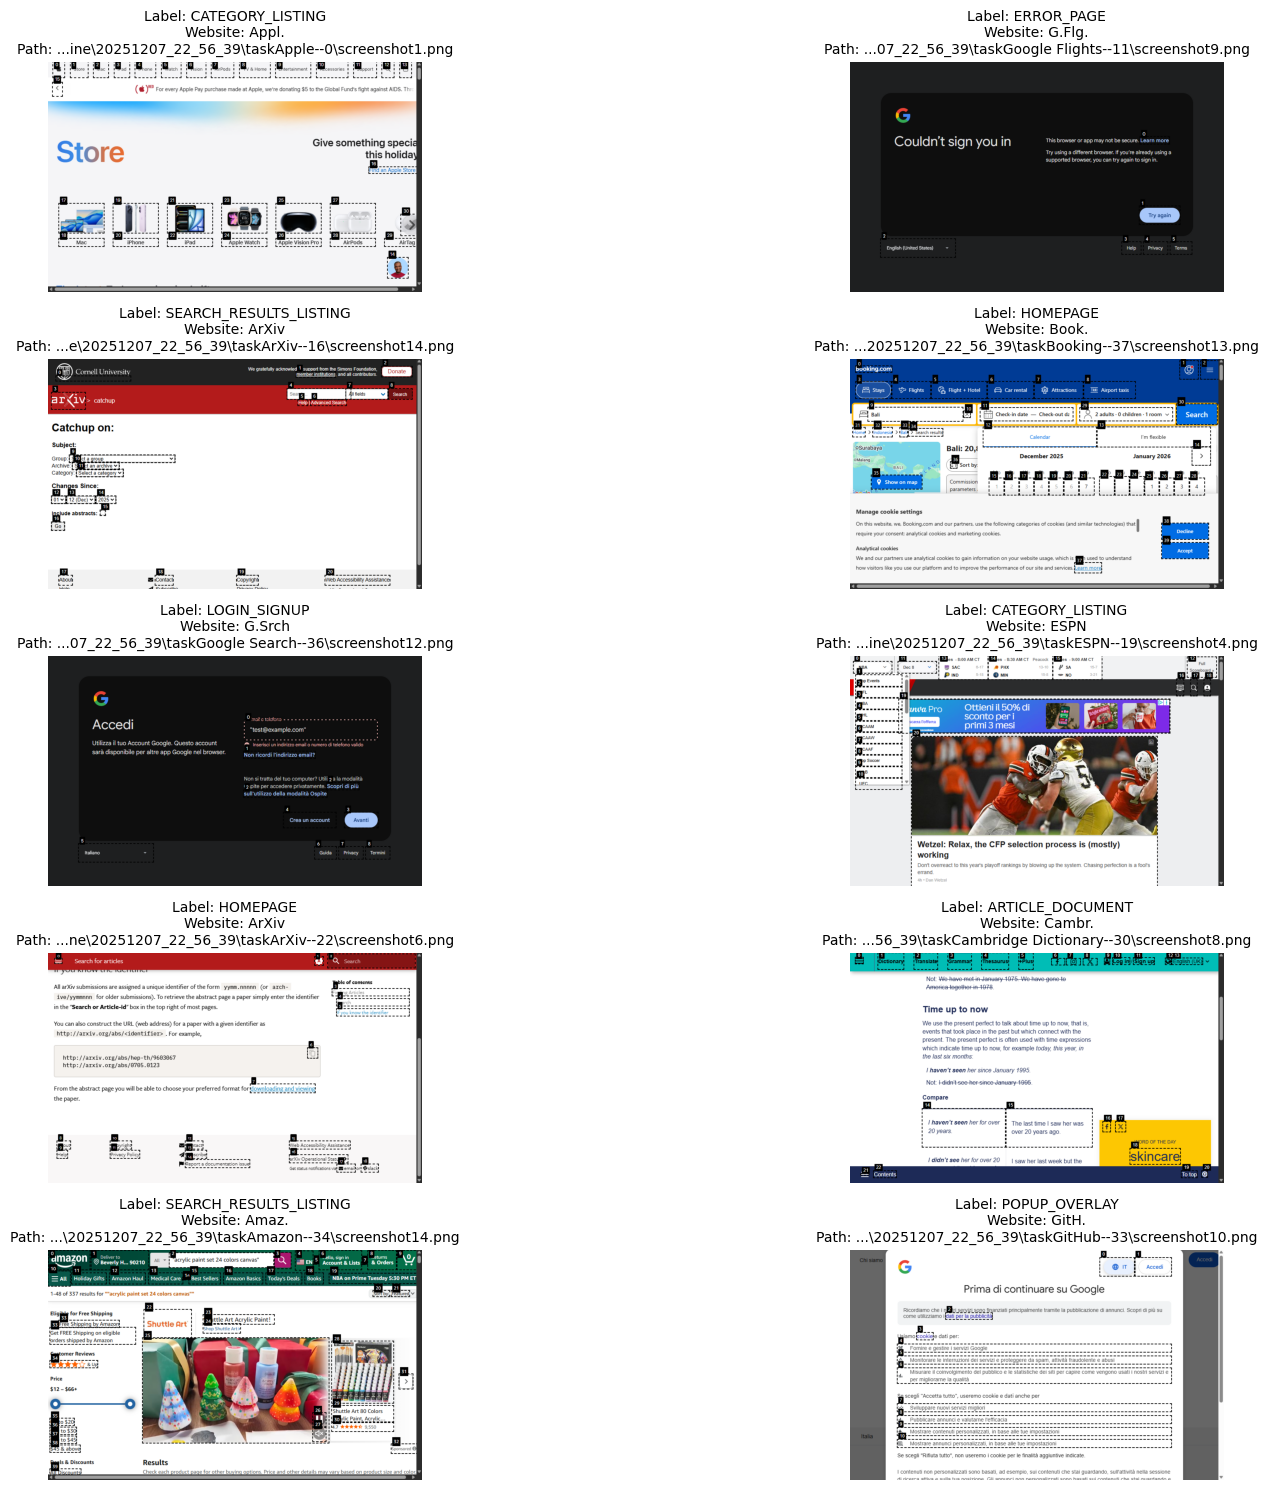


Sanity Check Complete.


In [35]:
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# --- ANALYSIS 4: IMAGE DIMENSIONS AND VISUAL SANITY CHECK ---

print(" Analysis 4: Image Dimensions and Visual Sanity Check")
print("=" * 60)

if 'image_path' in df.columns and not df.empty:
    
    # --- Part 1: Check Image Dimensions ---
    print("\n[Part 1] Analyzing dimensions of the first 100 images...")
    
    sizes = set()
    for image_path in df['image_path'].head(100):
        try:
            with Image.open(image_path) as img:
                sizes.add(img.size)
        except FileNotFoundError:
            print(f"  - WARNING: Image not found at path: {image_path}")
        except Exception as e:
            print(f"  - ERROR: Could not read image {image_path}. Reason: {e}")

    if sizes:
        print(f"\nFound {len(sizes)} unique image dimension(s):")
        for size in sizes:
            print(f"  - Width: {size[0]}px, Height: {size[1]}px")
    else:
        print("Could not determine image sizes.")

    # --- Part 2: Visual Sanity Check ---
    print("\n\n[Part 2] Displaying 10 randomly selected images with their labels...")
    
    # Ensure we have at least 10 images to sample from
    num_samples = min(10, len(df))
    
    if num_samples > 0:
        # Get a random sample of rows from the DataFrame
        random_samples = df.sample(n=num_samples)

        plt.figure(figsize=(20, 15))
        
        for i, (index, row) in enumerate(random_samples.iterrows()):
            image_path = row['image_path']
            label = row['label']
            website = row['website']
            
            ax = plt.subplot(5, 2, i + 1)
            try:
                img = Image.open(image_path)
                plt.imshow(img)
                plt.title(f"Label: {label}\nWebsite: {website}\nPath: ...{image_path[-50:]}", fontsize=10)
                plt.axis("off")
            except FileNotFoundError:
                ax.text(0.5, 0.5, 'Image Not Found', horizontalalignment='center', verticalalignment='center')
                plt.title(f"Label: {label}\nImage Not Found", fontsize=10)
                plt.axis("off")
        
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough data to display random samples.")
        
else:
    print("DataFrame is not loaded or does not contain 'image_path' column.")

print("\n" + "=" * 60)
print("Sanity Check Complete.")

Analysis 4: Image Dimensions and Visual Sanity Check
============================================================

[Part 1] Analyzing dimensions of the first 100 images...

Found 1 unique image dimension(s):
  - Width: 1006px, Height: 620px


[Part 2] Displaying 10 randomly selected images with their labels...

TODO
- filder out unsusuable website => all the wbesite with 0 success rate. I need to remove BBC News, Google Flights, Google Mpa, Google Search, Wolfr. Alpha [for this I have to wait for the label to be produced, so wait for now]

-  The avaible websites are: Allrecipes, Amazon, Apple, ArXiv, Booking, Cambr.,Dict., Coursera, ESPN, GitHub, Hug.Face
- how to split them? in train/test/validation? [for this I have to wait for the label to be produced, so wait for now]


--- maybe I can start doing this part below ---
- TODO: data augmentation of the miniorty classes to make them similar in number to the majority class
- check size of the images 
- start defining a model CNN (with training, tuning...) => use keras with hybernad as tuner?
- define the evalaution  metrics
